In [1]:
import numpy as np

In [2]:
import pandas as pd
df_2022 = pd.read_parquet("BRFSS_2022_combined.parquet", engine="pyarrow")
df_2023 = pd.read_parquet("BRFSS_2023_combined.parquet", engine="pyarrow")
df_2024 = pd.read_parquet("BRFSS_2024_combined.parquet", engine="pyarrow")


In [3]:
features = [
    "_ASTHMS1", "CHCKDNY2", "_DRDXAR2",
    "_EDUCAG", "_INCOMG1", "_AGE_G", "_SEX",
    "WTKG3", "HTM4", "_RFBMI5", "_BMI5",
    "_RFDRHV9", "_RFSMOK3", "_TOTINDA"
]

target = "DIABETE4"

In [4]:
def filter_brfss(df, features, target, year):
    cols = features + [target]

    cols = [c for c in cols if c in df.columns]

    df_filtered = df[cols].copy()
    df_filtered["year"] = year

    return df_filtered

In [5]:
df_2022_clean = filter_brfss(df_2022, features, target, 2022)
df_2023_clean = filter_brfss(df_2023, features, target, 2023)
df_2024_clean = filter_brfss(df_2024, features, target, 2024)

In [6]:
df_2024_clean.head()

,_ASTHMS1,CHCKDNY2,_DRDXAR2,_EDUCAG,_INCOMG1,_AGE_G,_SEX,WTKG3,HTM4,_RFBMI5,_BMI5,_RFDRHV9,_RFSMOK3,_TOTINDA,DIABETE4,year
0,3.0,2.0,1.0,2.0,9.0,6.0,2.0,5942.0,163.0,1.0,2249.0,1.0,1.0,1.0,3.0,2024
1,3.0,2.0,1.0,4.0,7.0,6.0,1.0,8165.0,178.0,2.0,2583.0,1.0,1.0,1.0,3.0,2024
2,3.0,2.0,1.0,3.0,9.0,5.0,1.0,8845.0,198.0,1.0,2253.0,1.0,2.0,1.0,3.0,2024
3,3.0,2.0,1.0,4.0,4.0,6.0,1.0,7484.0,173.0,2.0,2509.0,1.0,1.0,1.0,3.0,2024
4,3.0,2.0,2.0,3.0,2.0,4.0,1.0,5897.0,173.0,1.0,1977.0,1.0,1.0,2.0,3.0,2024


In [7]:
df_2022_clean.shape[1]

15

In [8]:
missing_in_2022 = list(set(df_2024_clean.columns.tolist()) - set(df_2022_clean.columns.tolist()))
print("Missing in 2022:", missing_in_2022)

Missing in 2022: ['_RFDRHV9']


In [9]:
missing_in_2023 = list(set(df_2024_clean.columns.tolist()) - set(df_2023_clean.columns.tolist()))
print("Missing in 2023:", missing_in_2023)

Missing in 2023: ['_RFDRHV9']


In [10]:
missing_in_2024 = list(set(df_2022_clean.columns.tolist()) - set(df_2023_clean.columns.tolist()))
print("Missing in 2024:", missing_in_2024)

Missing in 2024: []


In [11]:
all_missing = (set(df_2022_clean.columns) | set(df_2023_clean.columns) | set(df_2024_clean.columns)) - set(df_2022_clean.columns)
all_missing

{'_RFDRHV9'}

## Columns

In [12]:
df_final = pd.concat(
    [df_2024_clean, df_2023_clean, df_2022_clean],
    axis=0,
    ignore_index=True
)

In [13]:
df_final.shape[0]

1336125

In [14]:
print(df_final.shape)
print(df_final["year"].value_counts())
print(df_final.columns)

(1336125, 16)
year
2024    457670
2023    445132
2022    433323
Name: count, dtype: int64
Index(['_ASTHMS1', 'CHCKDNY2', '_DRDXAR2', '_EDUCAG', '_INCOMG1', '_AGE_G',
       '_SEX', 'WTKG3', 'HTM4', '_RFBMI5', '_BMI5', '_RFDRHV9', '_RFSMOK3',
       '_TOTINDA', 'DIABETE4', 'year'],
      dtype='object')


In [15]:
print("Class distribution:")
print(df_final[target].value_counts())

Class distribution:
DIABETE4
3.0    1103553
1.0     186753
4.0      32230
2.0      10484
7.0       2244
9.0        849
Name: count, dtype: int64


In [16]:
df_final = df_final[df_final[target].isin([1,3,4])].copy()

# Map 1=Diabetes, 4=Prediabetes to 1; 3= No to 0
df_final['DIABETE_BIN'] = df_final[target].replace({1:1, 4:1, 3:0})

In [17]:
binary_map = {"Yes":1, "No":0, "Y":1, "N":0, 1:1, 2:0}
binary_cols = ["_ASTHMS1", "CHCKDNY2", "_DRDXAR2", "_RFDRHV9", "_RFSMOK3"]

for col in binary_cols:
    df_final[col] = df_final[col].replace({1:1, 2:0, 7:np.nan, 9:np.nan})

 # 7 and 9 are unknown or refused

#Male=0, Female=1
df_final["_SEX"] = df_final["_SEX"].replace({1:0, 2:1})

## NAN values

In [18]:
nan_counts = df_final[features].isna().sum()

print("Number of missing values per feature:")
print(nan_counts)

nan_percent = (df_final[features].isna().mean() * 100).round(2)
print("\nPercentage of missing values per feature:")
print(nan_percent)

Number of missing values per feature:
_ASTHMS1     10559
CHCKDNY2      4937
_DRDXAR2      6761
_EDUCAG          0
_INCOMG1         0
_AGE_G           0
_SEX             0
WTKG3       110651
HTM4         73361
_RFBMI5          0
_BMI5       129849
_RFDRHV9    915394
_RFSMOK3     89163
_TOTINDA         0
dtype: int64

Percentage of missing values per feature:
_ASTHMS1     0.80
CHCKDNY2     0.37
_DRDXAR2     0.51
_EDUCAG      0.00
_INCOMG1     0.00
_AGE_G       0.00
_SEX         0.00
WTKG3        8.37
HTM4         5.55
_RFBMI5      0.00
_BMI5        9.82
_RFDRHV9    69.22
_RFSMOK3     6.74
_TOTINDA     0.00
dtype: float64


The huge jump in missingness is driven almost entirely by _RFDRHV9 being inconsistent across years, not a general data quality problem.

- Imputing it across the combined dataset would likely introduce bias by creating artificial cross-year patterns that don’t actually exist in the data

## Concistency

In [19]:
df_final["year"].value_counts(normalize=True)

,proportion
year,
2024,0.342706
2023,0.332852
2022,0.324442


- Balanced by year (no year dominates dataset too much)

In [20]:
df_final["DIABETE4"].value_counts(normalize=True)

,proportion
DIABETE4,
3.0,0.834422
1.0,0.141208
4.0,0.024370


- imbalance in target

## Distributions

In [21]:
df_final.groupby("year")["_BMI5"].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2022,389308.0,2847.193353,653.497485,1202.0,2410.0,2740.0,3162.0,9984.0
2023,392386.0,2852.198549,654.507700,1202.0,2413.0,2744.0,3171.0,9964.0
2024,410993.0,2854.774957,657.578042,1200.0,2414.0,2744.0,3175.0,9984.0


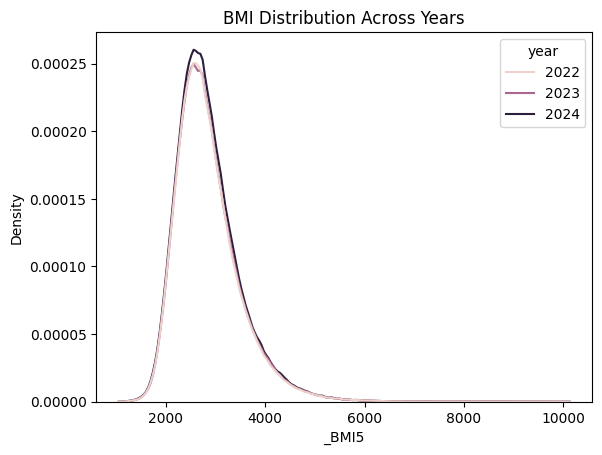

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df_final, x="_BMI5", hue="year")
plt.title("BMI Distribution Across Years")
plt.show()

##Quality

In [23]:
df_final.isnull().mean().sort_values(ascending=False)

,0
_RFDRHV9,0.692151
_BMI5,0.098182
WTKG3,0.083666
_RFSMOK3,0.067418
HTM4,0.055470
_ASTHMS1,0.007984
_DRDXAR2,0.005112
CHCKDNY2,0.003733
_INCOMG1,0.000000
_AGE_G,0.000000


### Checking how mean variates

In [24]:
for col in ["_BMI5", "_AGE_G", "_INCOMG1"]:
    print("\n", col)
    print(df_final.groupby("year")[col].mean())


 _BMI5
year
2022    2847.193353
2023    2852.198549
2024    2854.774957
Name: _BMI5, dtype: float64

 _AGE_G
year
2022    4.422915
2023    4.387750
2024    4.390730
Name: _AGE_G, dtype: float64

 _INCOMG1
year
2022    5.419098
2023    5.410446
2024    5.381153
Name: _INCOMG1, dtype: float64


In [25]:
df_final["DIABETE_BIN"].value_counts(normalize=True)

,proportion
DIABETE_BIN,
0.0,0.834422
1.0,0.165578


-  _RFDRHV9, is highly inconsistent across years and has about 69% missingness, making it unreliable for cross-year modeling.
- The dataset has a strong class imbalance in the diabetes target (about 83% “no diabetes”).